# mpc.dx on Pendulum - Dynamics Identifiability via Differentiable MPC

**Experiment overview.** An expert MPC controller knows the true pendulum physics ($g=10, m=1, l=1$) and produces optimal action sequences. A learner MPC controller shares the same cost but starts with randomly initialized dynamics parameters $(\hat{g}, \hat{m}, \hat{l})$, and minimizes the imitation loss $\mathcal{L} = \|u^* - \hat{u}\|^2$ by backpropagating through the differentiable iLQR solver.

**Key finding.** The pendulum dynamics $\ddot{\theta} = \frac{3g}{2l}\sin\theta + \frac{3u}{ml^2}$ depend only on two functional ratios: $\alpha = g/l$ and $\beta = 1/(ml^2)$. The optimizer recovers these ratios perfectly, but individual parameters $(g, m, l)$ are **not identifiable** — they scatter across a degenerate manifold of equivalent solutions. Imitation loss is a better evaluation metric than parameter MSE.

In [6]:
import os, sys, subprocess, time
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from types import SimpleNamespace

_REPO_ROOT = os.path.abspath('')
_MPC_LIB = os.path.join(_REPO_ROOT, 'mpc_pytorch_lib')
if _MPC_LIB not in sys.path:
    sys.path.insert(0, _MPC_LIB)

from mpc import mpc as mpc_module
from mpc.mpc import GradMethods, QuadCost
from mpc.env_dx.pendulum import PendulumDx

SCRIPT = os.path.join(_REPO_ROOT, 'imitation_nonconvex', 'fig3_identifiability.py')

%matplotlib inline
plt.rcParams['figure.dpi'] = 130

## 1. Configuration

In [7]:
TRUE_G, TRUE_M, TRUE_L = 10.0, 1.0, 1.0
TRUE_G_OVER_L = TRUE_G / TRUE_L       # 10.0
TRUE_INV_ML2 = 1.0 / (TRUE_M * TRUE_L**2)  # 1.0

cfg = SimpleNamespace(
    n_seeds=8,
    n_train=10,          # expert trajectories
    n_iter=2000,         # gradient steps per seed
    T=20,                # MPC horizon
    lqr_iter=500,        # iLQR iterations inside MPC
    lr=1e-2,             # RMSprop learning rate
    rms_alpha=0.5,       # RMSprop smoothing
    warmstart_reset=50,  # reset iLQR warmstart every N iters
    data_seed=42,        # fixed seed for expert data
    # Conservative initialization ranges (all 8 seeds converge)
    g_range=(5.0, 20.0),
    m_range=(0.3, 4.0),
    l_range=(0.3, 1.5),
)

print(f"True parameters:  g={TRUE_G}, m={TRUE_M}, l={TRUE_L}")
print(f"True ratios:      g/l={TRUE_G_OVER_L},  1/(ml²)={TRUE_INV_ML2}")
print(f"Seeds: {cfg.n_seeds}  |  n_train: {cfg.n_train}  |  n_iter: {cfg.n_iter}  |  T: {cfg.T}")

True parameters:  g=10.0, m=1.0, l=1.0
True ratios:      g/l=10.0,  1/(ml²)=1.0
Seeds: 8  |  n_train: 10  |  n_iter: 2000  |  T: 20


## 2. Generate Expert Data

The expert MPC uses the true pendulum dynamics to produce optimal action sequences from random initial states ($\theta \sim U(-\pi/2, \pi/2)$, $\dot{\theta} \sim U(-1, 1)$).

In [8]:
def make_expert_data(true_dx, cfg):
    """Generate n_train expert (xinit, u*) pairs using true dynamics."""
    torch.manual_seed(cfg.data_seed)
    N = cfg.n_train

    th = torch.FloatTensor(N).uniform_(-np.pi / 2, np.pi / 2)
    thdot = torch.FloatTensor(N).uniform_(-1.0, 1.0)
    xinit = torch.stack([torch.cos(th), torch.sin(th), thdot], dim=1)

    q_vec, p_vec = true_dx.get_true_obj()
    Q = torch.diag(q_vec).unsqueeze(0).unsqueeze(0).repeat(cfg.T, N, 1, 1)
    p = p_vec.unsqueeze(0).repeat(cfg.T, N, 1)

    _, u_mpc, _ = mpc_module.MPC(
        true_dx.n_state, true_dx.n_ctrl, cfg.T,
        u_lower=true_dx.lower, u_upper=true_dx.upper,
        lqr_iter=cfg.lqr_iter, verbose=0,
        exit_unconverged=False, detach_unconverged=True,
        linesearch_decay=true_dx.linesearch_decay,
        max_linesearch_iter=true_dx.max_linesearch_iter,
        grad_method=GradMethods.AUTO_DIFF, eps=true_dx.mpc_eps,
    )(xinit, QuadCost(Q, p), true_dx)

    return xinit, u_mpc.transpose(0, 1).detach()

true_dx = PendulumDx()
xinit, u_expert = make_expert_data(true_dx, cfg)
print(f"Expert data: xinit {xinit.shape}, u_expert {u_expert.shape}")

Expert data: xinit torch.Size([10, 3]), u_expert torch.Size([10, 20, 1])


## 3. Training Loop

For each seed: randomly initialize (g, m, l), run the learner MPC, compute imitation loss, backpropagate through the solver, update with RMSprop.

In [9]:
def run_learner_mpc(learn_dx, xinit, q_vec, p_vec, cfg, u_init=None):
    """Run MPC with the learner's dynamics. Gradient flows through env_params."""
    N = xinit.shape[0]
    Q = torch.diag(q_vec).unsqueeze(0).unsqueeze(0).repeat(cfg.T, N, 1, 1)
    p = p_vec.unsqueeze(0).repeat(cfg.T, N, 1)
    u_init_mpc = u_init.transpose(0, 1) if u_init is not None else None

    _, u_mpc, _ = mpc_module.MPC(
        learn_dx.n_state, learn_dx.n_ctrl, cfg.T,
        u_lower=learn_dx.lower, u_upper=learn_dx.upper,
        u_init=u_init_mpc,
        lqr_iter=cfg.lqr_iter, verbose=0,
        exit_unconverged=False, detach_unconverged=True,
        linesearch_decay=learn_dx.linesearch_decay,
        max_linesearch_iter=learn_dx.max_linesearch_iter,
        grad_method=GradMethods.AUTO_DIFF, eps=learn_dx.mpc_eps,
    )(xinit, QuadCost(Q, p), learn_dx)

    return u_mpc.transpose(0, 1)


def train_one_seed(seed, xinit, u_expert, true_dx, cfg):
    """Train one seed: randomly init (g,m,l), minimize imitation loss."""
    torch.manual_seed(seed)

    g_init = float(torch.FloatTensor(1).uniform_(*cfg.g_range))
    m_init = float(torch.FloatTensor(1).uniform_(*cfg.m_range))
    l_init = float(torch.FloatTensor(1).uniform_(*cfg.l_range))

    env_params = torch.tensor([g_init, m_init, l_init], dtype=torch.float32,
                               requires_grad=True)
    opt = optim.RMSprop(
        [{'params': env_params, 'lr': cfg.lr, 'alpha': cfg.rms_alpha}]
    )
    q_vec, p_vec = true_dx.get_true_obj()
    warmstart = torch.zeros(cfg.n_train, cfg.T, true_dx.n_ctrl)

    log = dict(im_loss=[], g=[], m=[], l=[], g_over_l=[], inv_ml2=[],
               g_init=g_init, m_init=m_init, l_init=l_init)

    for i in range(cfg.n_iter):
        if i % cfg.warmstart_reset == 0:
            warmstart = warmstart.detach().zero_()

        learn_dx = PendulumDx(params=env_params)
        u_pred = run_learner_mpc(learn_dx, xinit, q_vec, p_vec, cfg,
                                 u_init=warmstart)
        warmstart = u_pred.detach()
        im_loss = (u_expert - u_pred).pow(2).mean()

        g, m, l = env_params.detach().tolist()
        log['im_loss'].append(im_loss.item())
        log['g'].append(g); log['m'].append(m); log['l'].append(l)
        log['g_over_l'].append(g / l)
        log['inv_ml2'].append(1.0 / (m * l**2))

        if i % 500 == 0 or i == cfg.n_iter - 1:
            print(f'  iter {i:4d}  loss={im_loss.item():.5f}  '
                  f'g={g:.2f} m={m:.2f} l={l:.2f}  '
                  f'g/l={g/l:.3f}  1/(ml^2)={1/(m*l**2):.3f}')

        opt.zero_grad()
        im_loss.backward()
        opt.step()
        with torch.no_grad():
            env_params.clamp_(min=1e-3)

    return log

## 4. Run All Seeds in Parallel (Conservative Initialization)

All 8 seeds launch as separate subprocesses via `fig3_identifiability.py --single_seed` — the same pattern used in the original experiment. Each process saves a `seed_N.pt` checkpoint; we poll until all are done, then load and merge.

In [10]:
RESULTS_DIR = os.path.join('.', 'results')
OUT_CONS = os.path.join(RESULTS_DIR, 'conservative')
os.makedirs(OUT_CONS, exist_ok=True)

def launch_seeds(out_dir, n_seeds, extra_args=None):
    """Launch n_seeds separate processes via fig3_identifiability.py --single_seed."""
    procs = []
    for seed in range(n_seeds):
        ckpt = os.path.join(out_dir, f'seed_{seed}.pt')
        if os.path.exists(ckpt):
            print(f'  seed_{seed}.pt already exists, skipping.')
            continue
        cmd = [
            sys.executable, SCRIPT,
            '--single_seed', str(seed),
            '--out_dir', out_dir,
            '--n_iter', str(cfg.n_iter),
            '--n_train', str(cfg.n_train),
            '--T', str(cfg.T),
            '--lqr_iter', str(cfg.lqr_iter),
            '--lr', str(cfg.lr),
            '--rms_alpha', str(cfg.rms_alpha),
            '--warmstart_reset', str(cfg.warmstart_reset),
            '--data_seed', str(cfg.data_seed),
        ]
        if extra_args:
            cmd.extend(extra_args)
        procs.append((seed, subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)))
        print(f'  Launched seed {seed} (pid={procs[-1][1].pid})')
    return procs

def wait_and_collect(procs, out_dir, n_seeds):
    """Poll until all seeds finish, then load and merge."""
    for seed, proc in procs:
        ret = proc.wait()
        status = 'OK' if ret == 0 else f'FAILED (exit {ret})'
        print(f'  Seed {seed} finished: {status}')
        if ret != 0:
            print(proc.stdout.read().decode())

    all_logs = []
    for seed in range(n_seeds):
        ckpt = os.path.join(out_dir, f'seed_{seed}.pt')
        log = torch.load(ckpt, map_location='cpu')
        all_logs.append(log)
        print(f'  Loaded seed {seed}: loss={log["im_loss"][-1]:.2e}  '
              f'g/l={log["g_over_l"][-1]:.3f}  1/(ml^2)={log["inv_ml2"][-1]:.3f}')
    return all_logs

print(f'Launching {cfg.n_seeds} seeds in parallel (conservative)...')
procs = launch_seeds(OUT_CONS, cfg.n_seeds,
                     extra_args=['--g_range', '5.0', '20.0',
                                 '--m_range', '0.3', '4.0',
                                 '--l_range', '0.3', '1.5'])
all_logs = wait_and_collect(procs, OUT_CONS, cfg.n_seeds)

print('\n' + '='*60)
print(f'{"Seed":>4}  {"g/l":>8}  {"1/(ml^2)":>10}  {"loss":>10}  {"g":>7}  {"m":>7}  {"l":>7}')
for s, log in enumerate(all_logs):
    print(f'{s:>4}  {log["g_over_l"][-1]:>8.4f}  {log["inv_ml2"][-1]:>10.4f}  '
          f'{log["im_loss"][-1]:>10.2e}  {log["g"][-1]:>7.2f}  {log["m"][-1]:>7.2f}  {log["l"][-1]:>7.2f}')
print(f'{"true":>4}  {TRUE_G_OVER_L:>8.4f}  {TRUE_INV_ML2:>10.4f}  {"":>10}  {TRUE_G:>7.2f}  {TRUE_M:>7.2f}  {TRUE_L:>7.2f}')

Launching 8 seeds in parallel (conservative)...
  Launched seed 0 (pid=2420052)
  Launched seed 1 (pid=2420053)
  Launched seed 2 (pid=2420054)
  Launched seed 3 (pid=2420055)
  Launched seed 4 (pid=2420056)
  Launched seed 5 (pid=2420057)
  Launched seed 6 (pid=2420058)
  Launched seed 7 (pid=2420059)


  Seed 0 finished: OK
  Seed 1 finished: OK
  Seed 2 finished: OK
  Seed 3 finished: OK
  Seed 4 finished: OK
  Seed 5 finished: OK
  Seed 6 finished: OK
  Seed 7 finished: OK
  Loaded seed 0: loss=3.26e-04  g/l=9.949  1/(ml^2)=0.985
  Loaded seed 1: loss=5.04e-04  g/l=10.031  1/(ml^2)=0.995
  Loaded seed 2: loss=3.61e-04  g/l=9.943  1/(ml^2)=0.992
  Loaded seed 3: loss=5.25e-04  g/l=10.068  1/(ml^2)=1.016
  Loaded seed 4: loss=3.10e-04  g/l=10.047  1/(ml^2)=1.016
  Loaded seed 5: loss=7.63e-04  g/l=9.962  1/(ml^2)=1.008
  Loaded seed 6: loss=3.66e-04  g/l=9.981  1/(ml^2)=0.984
  Loaded seed 7: loss=2.77e-04  g/l=9.957  1/(ml^2)=0.985

Seed       g/l    1/(ml^2)        loss        g        m        l
   0    9.9493      0.9853    3.26e-04    10.66     0.88     1.07
   1   10.0307      0.9946    5.04e-04    15.40     0.43     1.53
   2    9.9431      0.9917    3.61e-04    12.70     0.62     1.28
   3   10.0681      1.0165    5.25e-04     7.06     2.00     0.70
   4   10.0474      1.0158

## 5. Results

### Plot 1: Imitation Loss Curves

All 8 seeds converge to loss < 1e-3 -- the learner perfectly mimics the expert.

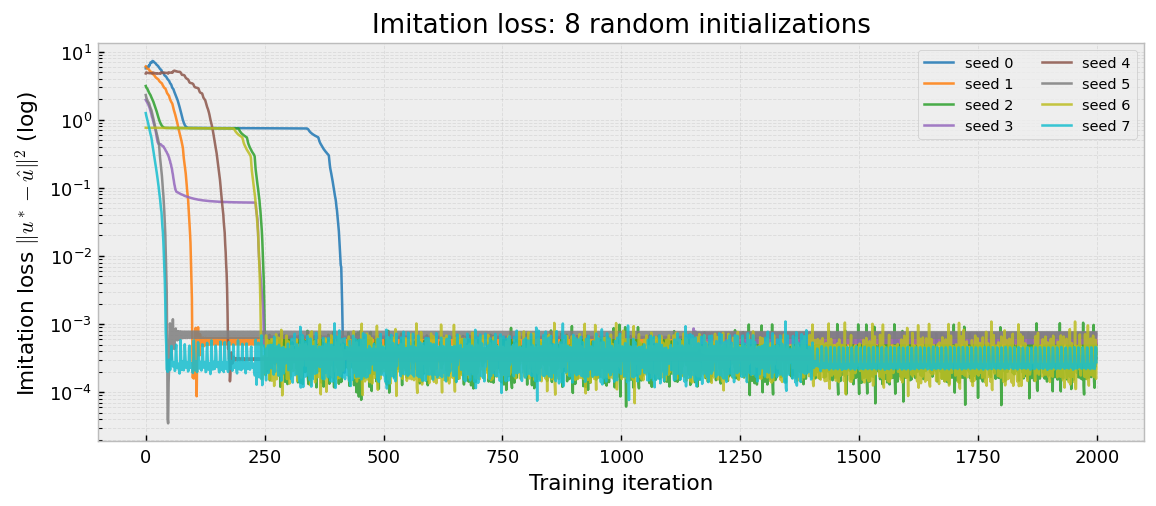

In [11]:
iters = np.arange(cfg.n_iter)
cmap = plt.cm.tab10
colors = [cmap(i / max(cfg.n_seeds - 1, 1)) for i in range(cfg.n_seeds)]

fig, ax = plt.subplots(figsize=(9, 4))
for s, log in enumerate(all_logs):
    ax.semilogy(iters, log['im_loss'], color=colors[s], alpha=0.85,
                linewidth=1.4, label=f'seed {s}')
ax.set_xlabel('Training iteration')
ax.set_ylabel(r'Imitation loss $\|u^* - \hat{u}\|^2$ (log)')
ax.set_title('Imitation loss: 8 random initializations')
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

### Plot 2: Individual Parameter Trajectories

Despite near-zero imitation loss, no parameter converges to its true value. Each seed settles at a different point.

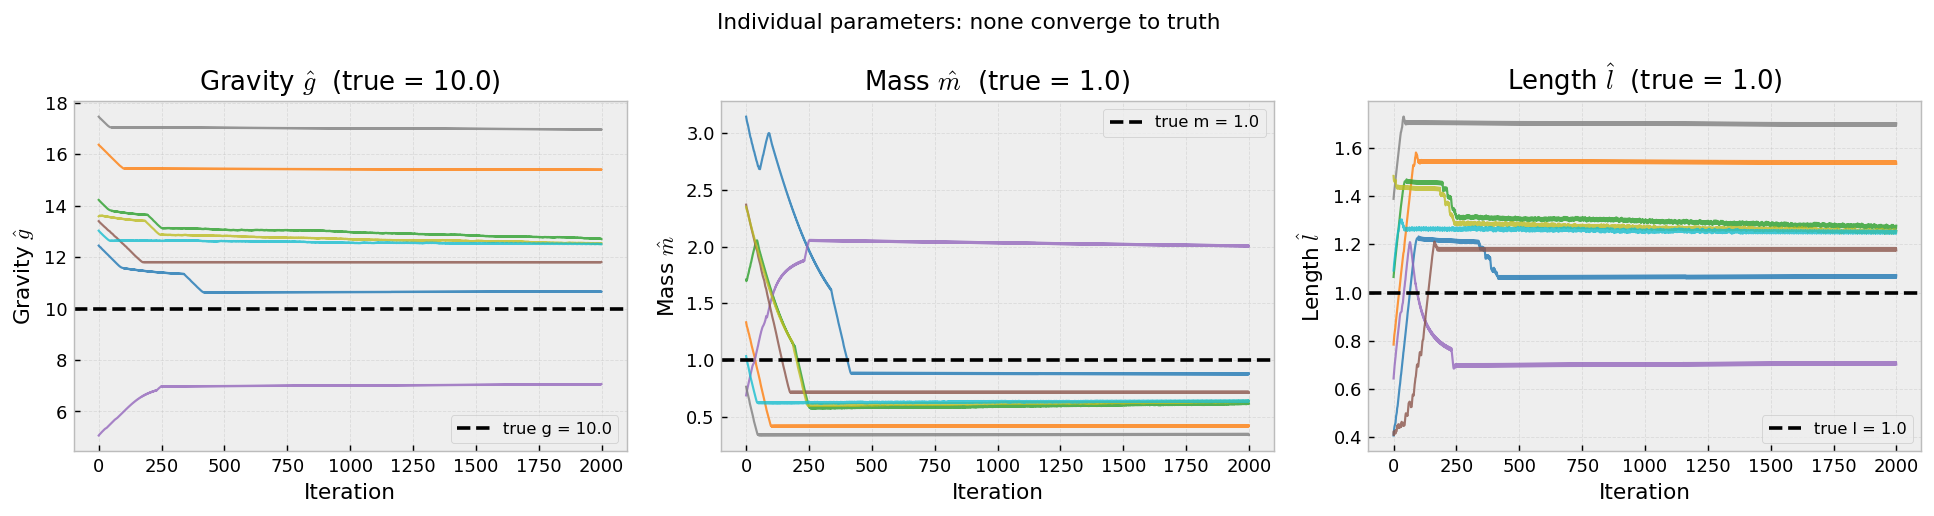

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
param_info = [
    ('g', TRUE_G, r'Gravity $\hat{g}$', 'g'),
    ('m', TRUE_M, r'Mass $\hat{m}$', 'm'),
    ('l', TRUE_L, r'Length $\hat{l}$', 'l'),
]
for ax, (key, true_val, ylabel, sym) in zip(axes, param_info):
    for s, log in enumerate(all_logs):
        ax.plot(iters, log[key], color=colors[s], alpha=0.8, linewidth=1.2)
    ax.axhline(true_val, color='black', linestyle='--', linewidth=2.0,
               label=f'true {sym} = {true_val}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}  (true = {true_val})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle('Individual parameters: none converge to truth', fontsize=12)
fig.tight_layout()
plt.show()

### Plot 3: The Identifiability Plot

The dynamics depend only on g/l and 1/(ml^2). All 8 seeds converge to the correct functional ratios (10, 1), despite wildly different individual (g, m, l). This is the degenerate manifold.

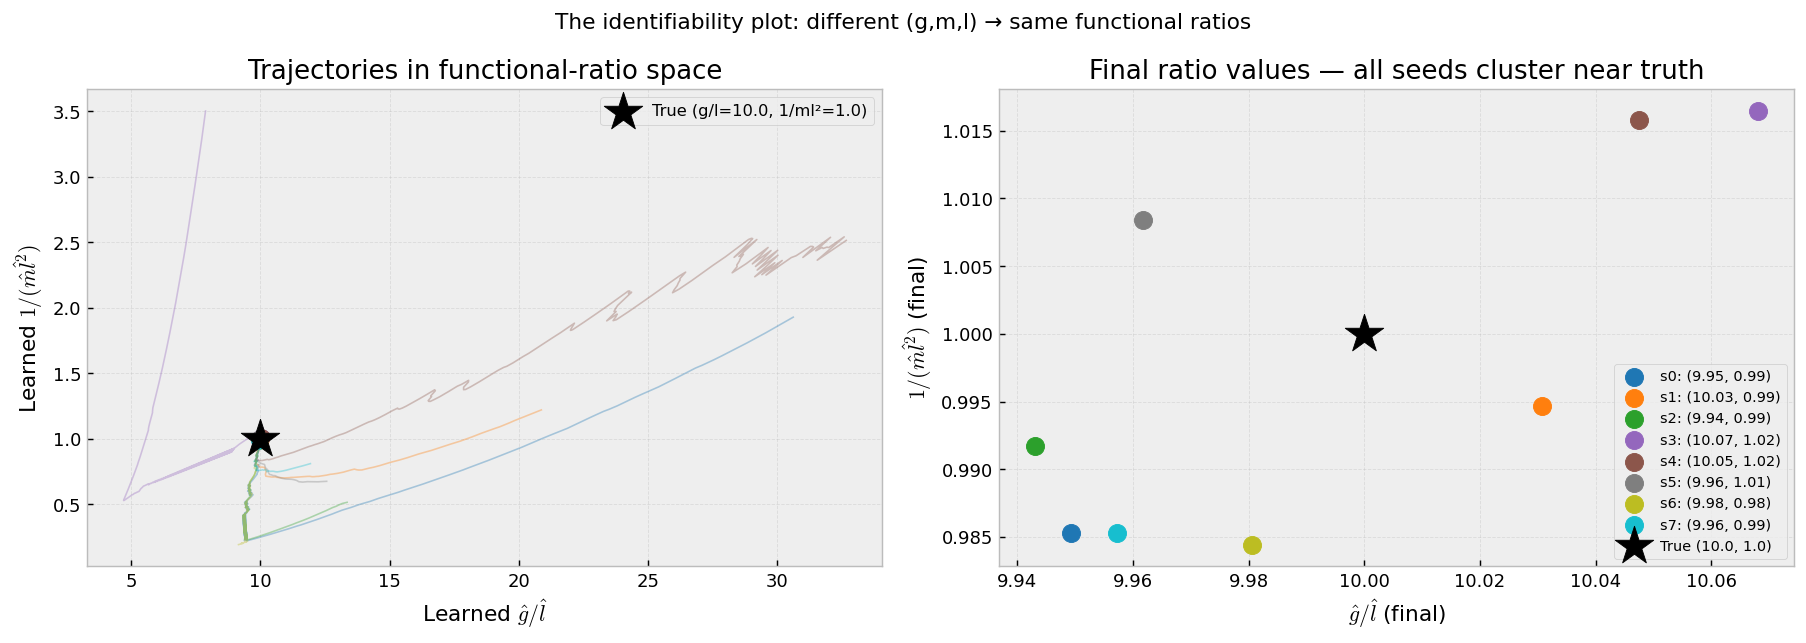

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for s, log in enumerate(all_logs):
    ax.plot(log['g_over_l'], log['inv_ml2'],
            color=colors[s], alpha=0.35, linewidth=0.9)
    ax.scatter(log['g_over_l'][-1], log['inv_ml2'][-1],
               color=colors[s], s=70, zorder=5)
ax.scatter(TRUE_G_OVER_L, TRUE_INV_ML2, marker='*', s=500,
           color='black', zorder=10,
           label=f'True (g/l={TRUE_G_OVER_L}, 1/ml²={TRUE_INV_ML2})')
ax.set_xlabel(r'Learned $\hat{g}/\hat{l}$')
ax.set_ylabel(r'Learned $1/(\hat{m}\hat{l}^2)$')
ax.set_title('Trajectories in functional-ratio space')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for s, log in enumerate(all_logs):
    ax.scatter(log['g_over_l'][-1], log['inv_ml2'][-1],
               color=colors[s], s=100, zorder=5,
               label=f's{s}: ({log["g_over_l"][-1]:.2f}, {log["inv_ml2"][-1]:.2f})')
ax.scatter(TRUE_G_OVER_L, TRUE_INV_ML2, marker='*', s=500,
           color='black', zorder=10, label=f'True ({TRUE_G_OVER_L}, {TRUE_INV_ML2})')
ax.set_xlabel(r'$\hat{g}/\hat{l}$ (final)')
ax.set_ylabel(r'$1/(\hat{m}\hat{l}^2)$ (final)')
ax.set_title('Final ratio values — all seeds cluster near truth')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

fig.suptitle('The identifiability plot: different (g,m,l) → same functional ratios',
             fontsize=12)
fig.tight_layout()
plt.show()

### Plot 4: Imitation Loss vs Parameter MSE (Figure 3 replica)

The paper's Figure 3 uses parameter MSE as "Model Loss." For the pendulum, this is misleading: it penalizes the unobservable direction along the degenerate manifold. Imitation loss is the right metric.

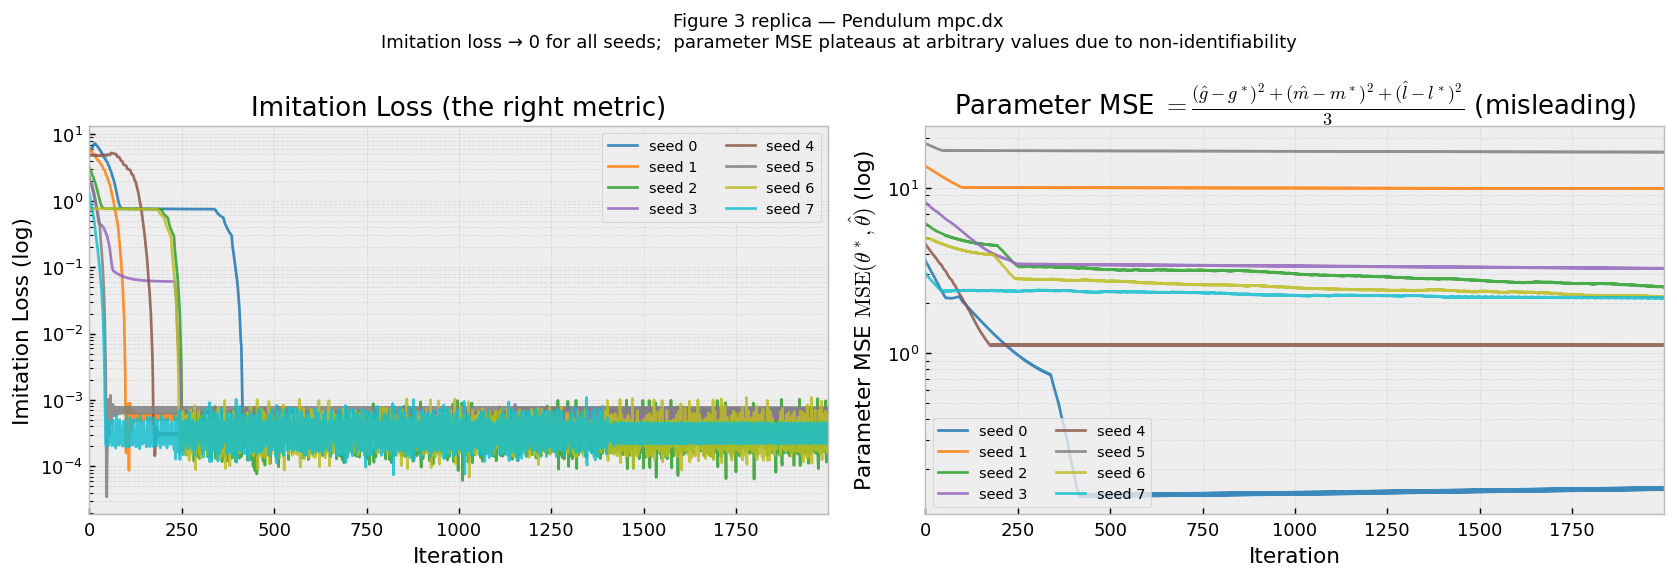

In [14]:
def compute_param_mse_series(g_traj, m_traj, l_traj):
    """Parameter MSE at every iteration: ((g-g*)^2 + (m-m*)^2 + (l-l*)^2) / 3."""
    g_arr = np.asarray(g_traj, dtype=np.float64)
    m_arr = np.asarray(m_traj, dtype=np.float64)
    l_arr = np.asarray(l_traj, dtype=np.float64)
    return ((g_arr - TRUE_G)**2 + (m_arr - TRUE_M)**2 + (l_arr - TRUE_L)**2) / 3.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for s, log in enumerate(all_logs):
    ax.semilogy(iters, log['im_loss'], color=colors[s], alpha=0.85,
                linewidth=1.5, label=f'seed {s}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Imitation Loss (log)')
ax.set_title('Imitation Loss (the right metric)')
ax.set_xlim(0, cfg.n_iter - 1)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for s, log in enumerate(all_logs):
    pmse = compute_param_mse_series(log['g'], log['m'], log['l'])
    ax.semilogy(iters, pmse, color=colors[s], alpha=0.85,
                linewidth=1.5, label=f'seed {s}')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'Parameter MSE $\mathrm{MSE}(\theta^*, \hat{\theta})$ (log)')
ax.set_title(r'Parameter MSE $= \frac{(\hat{g}-g^*)^2+(\hat{m}-m^*)^2+(\hat{l}-l^*)^2}{3}$ (misleading)')
ax.set_xlim(0, cfg.n_iter - 1)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which='both', alpha=0.3)

fig.suptitle('Figure 3 replica — Pendulum mpc.dx\n'
             'Imitation loss → 0 for all seeds;  parameter MSE plateaus at '
             'arbitrary values due to non-identifiability', fontsize=10)
fig.tight_layout()
plt.show()

### Summary Table

Per-seed outcomes. "Converged" means low loss AND correct ratios. "Compensated" means low loss but shifted individual parameters — which is expected given the degenerate manifold.

In [15]:
import pandas as pd

rows = []
for s, log in enumerate(all_logs):
    fg, fm, fl = log['g'][-1], log['m'][-1], log['l'][-1]
    gr = log['g_over_l'][-1]
    ir = log['inv_ml2'][-1]
    fl_ = log['im_loss'][-1]

    ratio_ok = abs(gr - TRUE_G_OVER_L) < 1.0
    inv_ok = abs(ir - TRUE_INV_ML2) < 0.15
    loss_ok = fl_ < 5e-3

    if loss_ok and ratio_ok and inv_ok:
        verdict = 'Converged'
    elif loss_ok:
        verdict = 'Compensated'
    elif ratio_ok and inv_ok:
        verdict = 'Right ratios'
    else:
        verdict = 'Not converged'

    rows.append({
        'Seed': s,
        'Init g': f'{log["g_init"]:.2f}', 'Init m': f'{log["m_init"]:.2f}',
        'Init l': f'{log["l_init"]:.2f}',
        'Final g': f'{fg:.3f}', 'Final m': f'{fm:.3f}', 'Final l': f'{fl:.3f}',
        'g/l': f'{gr:.3f}', '1/ml^2': f'{ir:.3f}',
        'Loss': f'{fl_:.2e}', 'Verdict': verdict,
    })

df = pd.DataFrame(rows)
df.style.set_caption('Per-seed outcomes')

,Seed,Init g,Init m,Init l,Final g,Final m,Final l,g/l,1/ml^2,Loss,Verdict
0,0,12.44,3.14,0.41,10.656,0.885,1.071,9.949,0.985,3.26e-04,Converged
1,1,16.36,1.33,0.78,15.396,0.427,1.535,10.031,0.995,5.04e-04,Converged
2,2,14.22,1.71,1.06,12.701,0.618,1.277,9.943,0.992,3.61e-04,Converged
3,3,5.06,0.69,0.64,7.060,2.001,0.701,10.068,1.016,5.25e-04,Converged
4,4,13.39,2.37,0.41,11.806,0.713,1.175,10.047,1.016,3.10e-04,Converged
5,5,17.45,0.77,1.39,16.956,0.342,1.702,9.962,1.008,7.63e-04,Converged
6,6,13.58,2.35,1.48,12.531,0.644,1.256,9.981,0.984,3.66e-04,Converged
7,7,13.02,1.04,1.09,12.504,0.644,1.256,9.957,0.985,2.77e-04,Converged


## 6. Unrestricted Initialization (Optional Ablation)

The conservative ranges above ensure iLQR stability. Widening the ranges (g up to 30, m up to 5, l up to 3) tests robustness — some seeds may diverge.

In [16]:
OUT_UNR = os.path.join(RESULTS_DIR, 'unrestricted')
os.makedirs(OUT_UNR, exist_ok=True)

print(f'Launching {cfg.n_seeds} seeds in parallel (unrestricted)...')
procs_unr = launch_seeds(OUT_UNR, cfg.n_seeds,
                         extra_args=['--g_range', '3.0', '30.0',
                                     '--m_range', '0.2', '5.0',
                                     '--l_range', '0.2', '3.0'])
all_logs_unr = wait_and_collect(procs_unr, OUT_UNR, cfg.n_seeds)

print('\n' + '='*60)
print(f'{"Seed":>4}  {"g/l":>8}  {"1/(ml^2)":>10}  {"loss":>10}')
for s, log in enumerate(all_logs_unr):
    print(f'{s:>4}  {log["g_over_l"][-1]:>8.4f}  {log["inv_ml2"][-1]:>10.4f}  '
          f'{log["im_loss"][-1]:>10.2e}')

Launching 8 seeds in parallel (unrestricted)...
  Launched seed 0 (pid=2422843)
  Launched seed 1 (pid=2422844)
  Launched seed 2 (pid=2422845)
  Launched seed 3 (pid=2422846)
  Launched seed 4 (pid=2422847)
  Launched seed 5 (pid=2422848)
  Launched seed 6 (pid=2422849)
  Launched seed 7 (pid=2422877)
  Seed 0 finished: OK
  Seed 1 finished: OK
  Seed 2 finished: OK
  Seed 3 finished: OK
  Seed 4 finished: OK
  Seed 5 finished: OK
  Seed 6 finished: OK
  Seed 7 finished: OK
  Loaded seed 0: loss=6.74e+00  g/l=31.267  1/(ml^2)=1.002
  Loaded seed 1: loss=1.34e-03  g/l=10.016  1/(ml^2)=0.981
  Loaded seed 2: loss=8.35e-04  g/l=10.023  1/(ml^2)=0.988
  Loaded seed 3: loss=9.06e-04  g/l=9.902  1/(ml^2)=0.982
  Loaded seed 4: loss=6.21e-04  g/l=9.959  1/(ml^2)=1.006
  Loaded seed 5: loss=2.34e-03  g/l=10.009  1/(ml^2)=0.972
  Loaded seed 6: loss=9.13e-04  g/l=10.021  1/(ml^2)=0.986
  Loaded seed 7: loss=7.82e-04  g/l=9.962  1/(ml^2)=1.009

Seed       g/l    1/(ml^2)        loss
   0   31.2

### Unrestricted: Plots

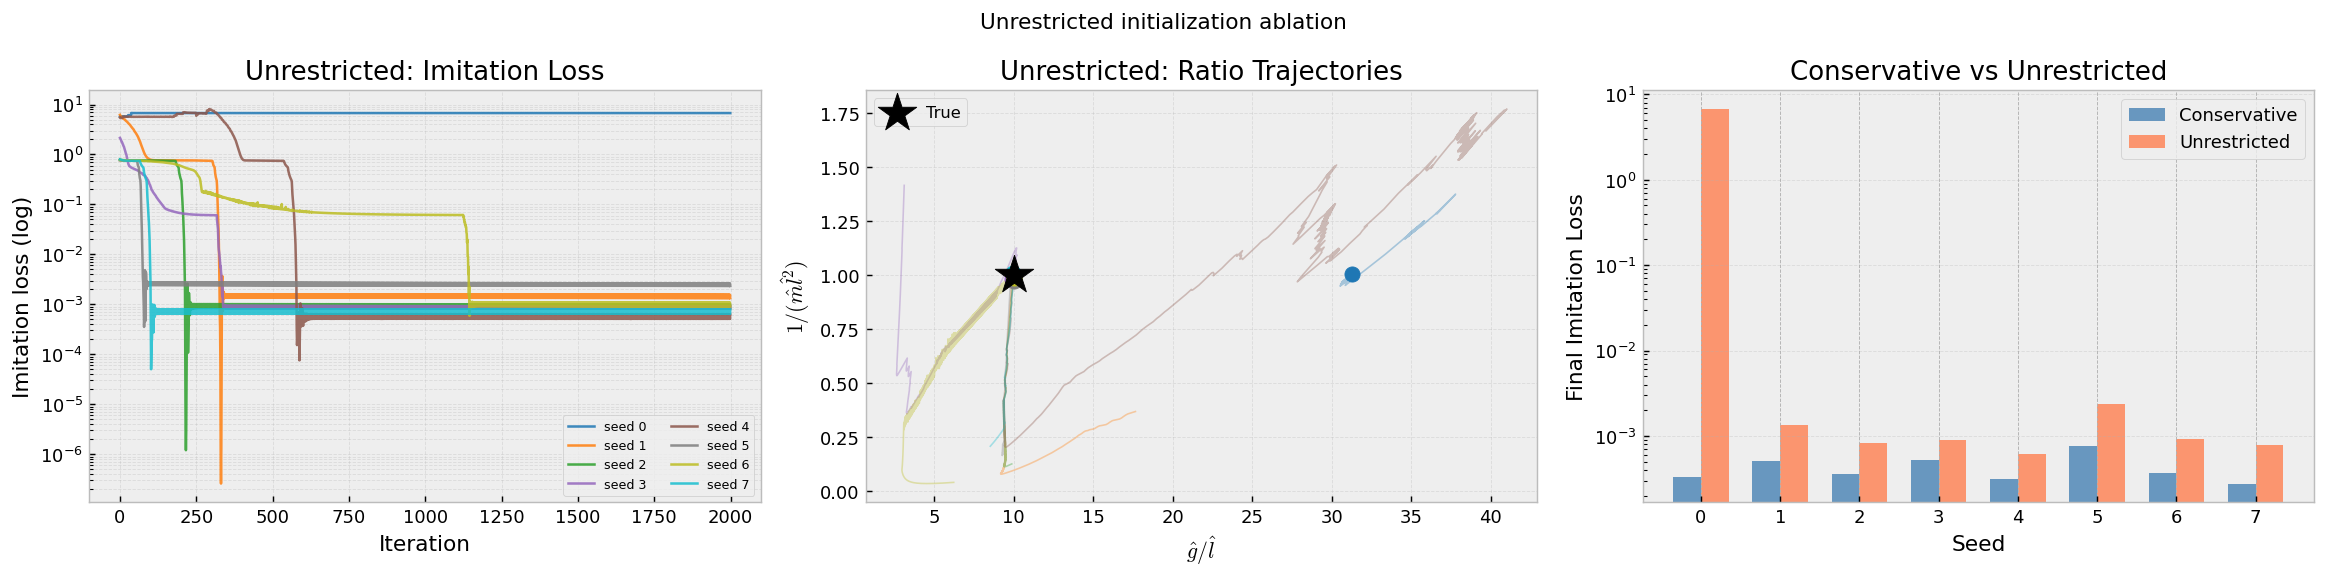

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Loss curves
ax = axes[0]
for s, log in enumerate(all_logs_unr):
    ax.semilogy(iters, log['im_loss'], color=colors[s], alpha=0.85,
                linewidth=1.4, label=f'seed {s}')
ax.set_xlabel('Iteration'); ax.set_ylabel('Imitation loss (log)')
ax.set_title('Unrestricted: Imitation Loss')
ax.legend(fontsize=7, ncol=2); ax.grid(True, which='both', alpha=0.3)

# Identifiability scatter
ax = axes[1]
for s, log in enumerate(all_logs_unr):
    ax.plot(log['g_over_l'], log['inv_ml2'], color=colors[s], alpha=0.35, linewidth=0.9)
    ax.scatter(log['g_over_l'][-1], log['inv_ml2'][-1], color=colors[s], s=70, zorder=5)
ax.scatter(TRUE_G_OVER_L, TRUE_INV_ML2, marker='*', s=500, color='black', zorder=10, label='True')
ax.set_xlabel(r'$\hat{g}/\hat{l}$'); ax.set_ylabel(r'$1/(\hat{m}\hat{l}^2)$')
ax.set_title('Unrestricted: Ratio Trajectories')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Comparison: conservative vs unrestricted
ax = axes[2]
conv_losses = [log['im_loss'][-1] for log in all_logs]
unr_losses = [log['im_loss'][-1] for log in all_logs_unr]
x = np.arange(cfg.n_seeds)
width = 0.35
ax.bar(x - width/2, conv_losses, width, label='Conservative', color='steelblue', alpha=0.8)
ax.bar(x + width/2, unr_losses, width, label='Unrestricted', color='coral', alpha=0.8)
ax.set_xlabel('Seed'); ax.set_ylabel('Final Imitation Loss')
ax.set_title('Conservative vs Unrestricted')
ax.set_yscale('log'); ax.set_xticks(x)
ax.legend(); ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Unrestricted initialization ablation', fontsize=12)
fig.tight_layout()
plt.show()

## 7. Save All Results

Save the logs so we don't need to re-train.

In [18]:
torch.save(all_logs, os.path.join(OUT_CONS, 'logs.pt'))
torch.save(all_logs_unr, os.path.join(OUT_UNR, 'logs.pt'))

print(f"Saved merged logs to {OUT_CONS}/logs.pt")
print(f"Saved merged logs to {OUT_UNR}/logs.pt")
print(f"\nAll results in: {RESULTS_DIR}/")
!ls -R {RESULTS_DIR}

Saved merged logs to ./results/conservative/logs.pt
Saved merged logs to ./results/unrestricted/logs.pt

All results in: ./results/
./results:
conservative  unrestricted

./results/conservative:
logs.pt    seed_1.pt  seed_3.pt  seed_5.pt  seed_7.pt
seed_0.pt  seed_2.pt  seed_4.pt  seed_6.pt

./results/unrestricted:
logs.pt    seed_1.pt  seed_3.pt  seed_5.pt  seed_7.pt
seed_0.pt  seed_2.pt  seed_4.pt  seed_6.pt
